# Multiple linear regression on  index price

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
df_index = pd.read_csv("economic_index.csv")
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [6]:
## Drop unncessary columns
#df_index.drop(columns = ["Unnamed: 0","year","month"],axis = 1,inplace = True)
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [7]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

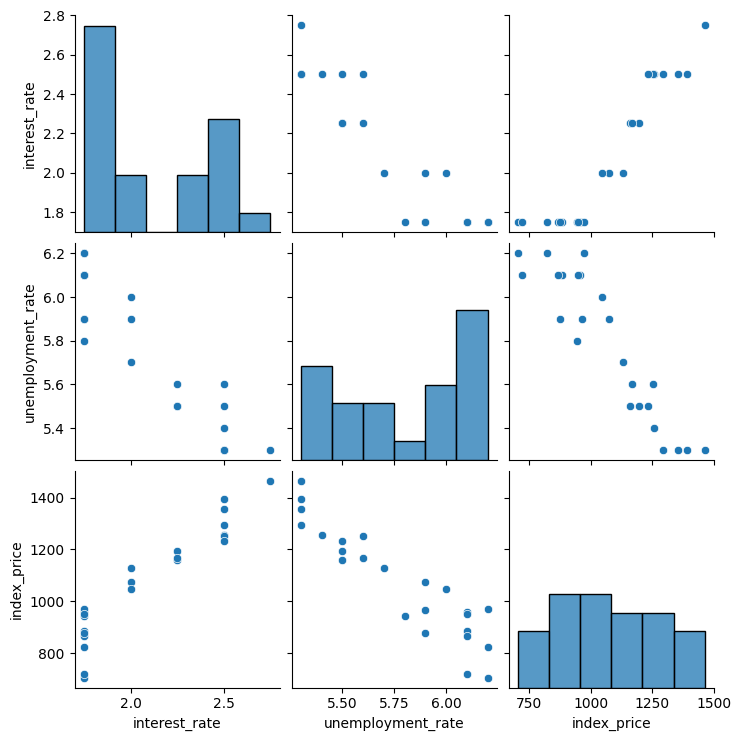

In [9]:
import seaborn as sns
sns.pairplot(df_index)

In [10]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


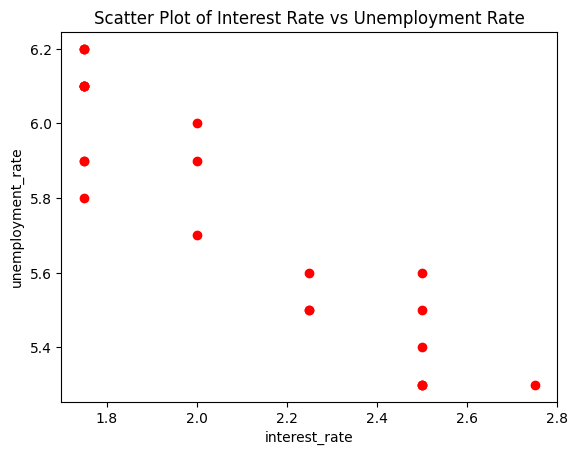

In [11]:
## Visualize the datapoitns more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'], color = 'red')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')
plt.title('Scatter Plot of Interest Rate vs Unemployment Rate')
plt.show()

In [12]:
## Independent and dependent variables
X = df_index[['interest_rate','unemployment_rate']]
# x = df_index.iloc[:,:-1]
y = df_index['unemployment_rate']
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [13]:
# Train test split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25, random_state = 42)


<Axes: xlabel='interest_rate', ylabel='index_price'>

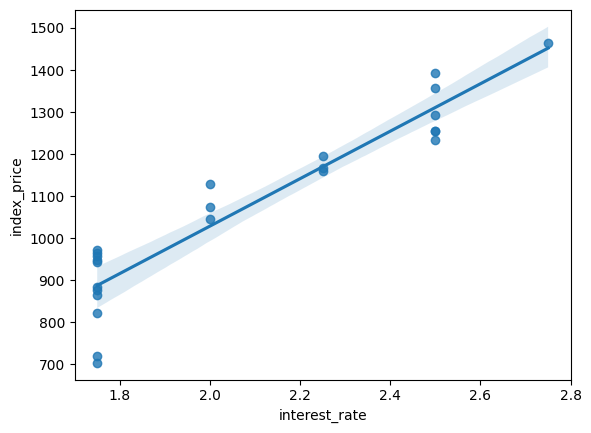

In [17]:
import seaborn as sns

sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

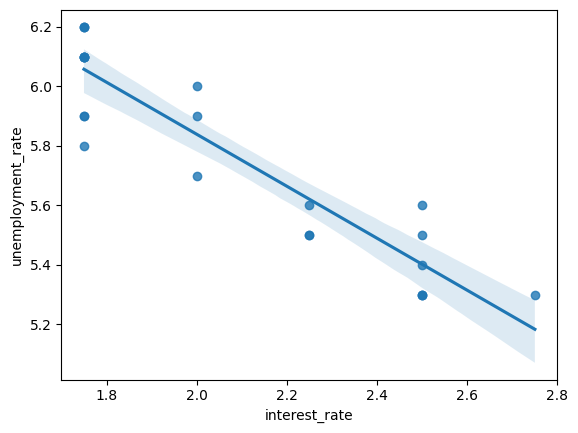

In [18]:
sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])


In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [20]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
## Cross validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring = 'neg_mean_squared_error', cv = 3)
np.mean(validation_score)

np.float64(-2.629536350736706e-31)

In [23]:
## prediction
y_pred = regression.predict(X_test)
y_pred

array([5.51314617, 6.20780415, 5.31467246, 6.10856729, 5.91009358,
       5.61238302])

In [25]:
## Performance metric
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("Mean Squared Error:",mse)
print("Mean Absolute Error:",mae)
print("Root Mean Squared Error:",rmse)
print("R-squared:",r2)

Mean Squared Error: 0.0001296042573128576
Mean Absolute Error: 0.011111111111111072
Root Mean Squared Error: 0.011384386558478133
R-squared: 0.9987721701938782


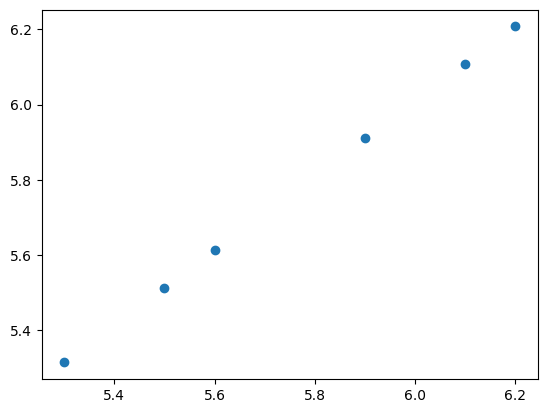

In [30]:
plt.scatter(y_test,y_pred)


In [34]:
residuals = y_test - y_pred
print(residuals)

8    -0.013146
16   -0.007804
0    -0.014672
18   -0.008567
11   -0.010094
9    -0.012383
Name: unemployment_rate, dtype: float64


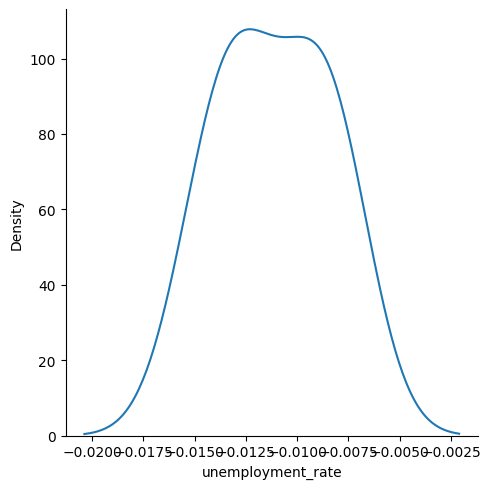

In [29]:
# plot the residuals
sns.displot(residuals,kind = 'kde')

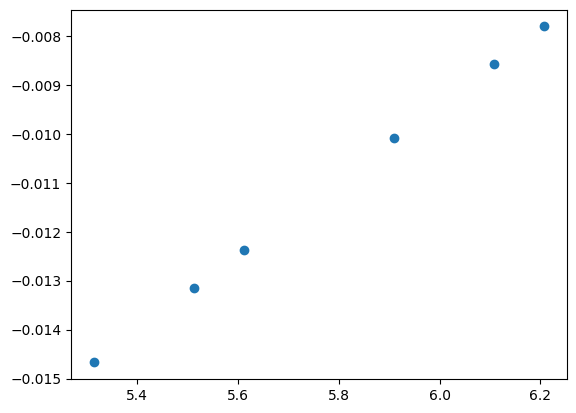

In [35]:
## scatter plot with respect to predicitons and residuals
plt.scatter(y_pred,residuals)


In [36]:
## OLS linear regession using statsmodels
import statsmodels.api as sm
model = sm.OLS(y_train,X_train).fit()
prediction = model.predict(X_test)
print(prediction)
print(model.summary())

[-0.26463161  0.43002637 -0.46310532  0.33078951  0.13231581 -0.16539476]
                                 OLS Regression Results                                
Dep. Variable:      unemployment_rate   R-squared (uncentered):                   0.003
Model:                            OLS   Adj. R-squared (uncentered):             -0.122
Method:                 Least Squares   F-statistic:                            0.02491
Date:                Sat, 29 Aug 2026   Prob (F-statistic):                       0.975
Time:                        10:19:25   Log-Likelihood:                         -57.113
No. Observations:                  18   AIC:                                      118.2
Df Residuals:                      16   BIC:                                      120.0
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t   

In [37]:
print(regression.coef_)

[-4.64823664e-17  3.22413736e-01]
